# Data Preprocessing — Credit Risk Modeling

## Objective
Prepare and clean the Home Credit dataset for building a credit risk (Probability of Default) model.

## Business Context
A lending institution wants to predict whether a borrower will default on a loan.

Target Variable:
- TARGET = 1 → Default
- TARGET = 0 → Non-default

In [1]:
## Install necessary libraries

%pip install -r requirements.txt

## Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\hiral\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
## Load the dataset

df = pd.read_csv("../01_data/home_credit/application_train.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../01_data/home_credit/application_train.csv'

In [ ]:
## Check the shape after loading the dataset

print(df.shape)
df.head()

(307511, 50)


,TARGET,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,DAYS_BIRTH,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,DAYS_LAST_PHONE_CHANGE,CODE_GENDER_M,DAYS_ID_PUBLISH,REG_CITY_NOT_WORK_CITY,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_INCOME_TYPE_Pensioner,ORGANIZATION_TYPE_XNA,FLAG_EMP_PHONE,DAYS_EMPLOYED,REG_CITY_NOT_LIVE_CITY,FLAG_DOCUMENT_3,OCCUPATION_TYPE_Laborers,DAYS_REGISTRATION,EMERGENCYSTATE_MODE_Unknown,HOUSETYPE_MODE_block of flats,FLOORSMAX_AVG,FLOORSMAX_MEDI,AMT_GOODS_PRICE,WALLSMATERIAL_MODE_Unknown,FLOORSMAX_MODE,OCCUPATION_TYPE_Unknown,ELEVATORS_AVG,REGION_POPULATION_RELATIVE,ELEVATORS_MEDI,ELEVATORS_MODE,WALLSMATERIAL_MODE_Panel,DEF_30_CNT_SOCIAL_CIRCLE,LIVE_CITY_NOT_WORK_CITY,TOTALAREA_MODE,DEF_60_CNT_SOCIAL_CIRCLE,LIVINGAREA_AVG,LIVINGAREA_MEDI,NAME_CONTRACT_TYPE_Revolving loans,OCCUPATION_TYPE_Drivers,AMT_CREDIT,NAME_HOUSING_TYPE_With parents,LIVINGAREA_MODE,ORGANIZATION_TYPE_Self-employed,FLAG_DOCUMENT_6,NAME_HOUSING_TYPE_House / apartment,FLAG_WORK_PHONE
0,1,0.262949,0.139376,0.116257,-9461,2,2,True,False,-1134.0,True,-2120,0,True,False,False,1,-637.0,0,1,True,-3648.0,False,True,0.0833,0.0833,351000.0,False,0.0833,False,0.00,0.018801,0.00,0.0000,False,2.0,0,0.0149,2.0,0.0190,0.0193,False,False,406597.5,False,0.0198,False,0,True,0
1,0,0.622246,0.535276,0.311267,-16765,1,1,False,True,-828.0,False,-291,0,False,False,False,1,-1188.0,0,1,False,-1186.0,False,True,0.2917,0.2917,1129500.0,False,0.2917,False,0.08,0.003541,0.08,0.0806,False,0.0,0,0.0714,0.0,0.0549,0.0558,False,False,1293502.5,False,0.0554,False,0,True,0
2,0,0.555912,0.729567,0.505998,-19046,2,2,True,False,-815.0,True,-2531,0,True,False,False,1,-225.0,0,0,True,-4260.0,True,False,0.1667,0.1667,135000.0,True,0.1667,False,0.00,0.010032,0.00,0.0000,False,0.0,0,0.0688,0.0,0.0745,0.0749,True,False,135000.0,False,0.0731,False,0,True,1
3,0,0.650442,0.535276,0.505998,-19005,2,2,True,False,-617.0,False,-2437,0,True,False,False,1,-3039.0,0,1,True,-9833.0,True,False,0.1667,0.1667,297000.0,True,0.1667,False,0.00,0.008019,0.00,0.0000,False,0.0,0,0.0688,0.0,0.0745,0.0749,False,False,312682.5,False,0.0731,False,0,True,0
4,0,0.322738,0.535276,0.505998,-19932,2,2,True,False,-1106.0,True,-3458,1,True,False,False,1,-3038.0,0,0,False,-4311.0,True,False,0.1667,0.1667,513000.0,True,0.1667,False,0.00,0.028663,0.00,0.0000,False,0.0,1,0.0688,0.0,0.0745,0.0749,False,False,513000.0,False,0.0731,False,0,True,0


In [ ]:
## Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [ ]:
## Check for missing values and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [ ]:
## Summary statistics of the dataset

df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

## Data Structure Summary

- Dataset contains borrower-level information
- Includes demographic, financial, and external risk scores
- Target variable indicates default behavior

In [ ]:
## Analyze the target variable distribution

df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [ ]:
## Analyze the target variable distribution in percentage

df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

## Key Insight

- Dataset is highly imbalanced (~8% defaults)
- This reflects real-world lending data

Will handle imbalance in modeling stage

In [ ]:
## Check for missing values in each column

missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64

In [ ]:
## Drop columns with more than 60% missing values

missing = df.isnull().mean()

cols_to_drop = missing[missing > 0.6].index

df = df.drop(columns=cols_to_drop)

In [ ]:
## Select numerical and categorical columns

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [ ]:
## Fill missing values in numerical columns with median

num_cols_existing = [col for col in num_cols if col in df.columns]
df[num_cols_existing] = df[num_cols_existing].fillna(df[num_cols_existing].median())

In [ ]:
## Impute missing values in categorical columns with "Unknown"

cat_cols_existing = [col for col in cat_cols if col in df.columns]
df[cat_cols_existing] = df[cat_cols_existing].fillna("Unknown")

In [ ]:
## Remove constant features

nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index

df = df.drop(columns=constant_cols)

In [ ]:
## Cap outliers (1st–99th percentile)

for col in num_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(q1, q99)

In [ ]:
## One-hot encode categorical variables

df = pd.get_dummies(df, drop_first=True)

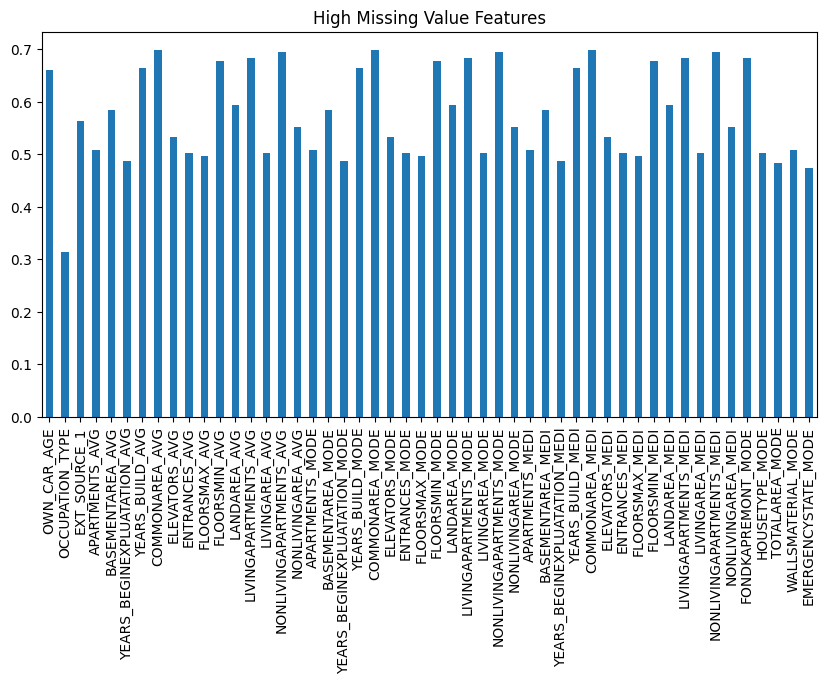

In [ ]:
## Visualize the missing values

missing[missing > 0.3].plot(kind="bar", figsize=(10,5))
plt.title("High Missing Value Features")
plt.show()

## Data Quality Strategy

- Dataset initially had significant missing values
- Features with >60% missing values were dropped
- Numeric features were imputed using median (robust to outliers)
- Categorical features were imputed with "Unknown"
- One-hot encoding applied to categorical variables
- Dataset is now clean and ready for modeling

In [ ]:
## Correlation analysis with the target variable

corr = df.corr(numeric_only=True)["TARGET"].sort_values(ascending=False)

In [ ]:
## Top positive drivers of default

corr.head(10)

TARGET                                               1.000000
DAYS_BIRTH                                           0.078220
REGION_RATING_CLIENT_W_CITY                          0.060893
REGION_RATING_CLIENT                                 0.058899
NAME_INCOME_TYPE_Working                             0.057481
DAYS_LAST_PHONE_CHANGE                               0.055282
CODE_GENDER_M                                        0.054713
DAYS_ID_PUBLISH                                      0.051448
REG_CITY_NOT_WORK_CITY                               0.050994
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
Name: TARGET, dtype: float64

In [ ]:
## Top negative drivers of default

corr.tail(10)

FLAG_DOCUMENT_14             NaN
FLAG_DOCUMENT_15             NaN
FLAG_DOCUMENT_16             NaN
FLAG_DOCUMENT_17             NaN
FLAG_DOCUMENT_18             NaN
FLAG_DOCUMENT_19             NaN
FLAG_DOCUMENT_20             NaN
FLAG_DOCUMENT_21             NaN
AMT_REQ_CREDIT_BUREAU_HOUR   NaN
AMT_REQ_CREDIT_BUREAU_DAY    NaN
Name: TARGET, dtype: float64

In [ ]:
## Correlation of features with target variable

corr.tail(10)

FLOORSMAX_AVG                          -0.039385
AMT_GOODS_PRICE                        -0.039623
HOUSETYPE_MODE_block of flats          -0.040594
DAYS_EMPLOYED                          -0.044932
ORGANIZATION_TYPE_XNA                  -0.045987
NAME_INCOME_TYPE_Pensioner             -0.046209
NAME_EDUCATION_TYPE_Higher education   -0.056593
EXT_SOURCE_1                           -0.098887
EXT_SOURCE_3                           -0.155892
EXT_SOURCE_2                           -0.160295
Name: TARGET, dtype: float64

In [ ]:
## Select top features based on correlation

top_features = corr.abs().sort_values(ascending=False).head(50).index

df = df[top_features]

## Key Drivers of Default

Positive correlation → increases default risk  
Negative correlation → reduces default risk  

Top predictors of default:

- EXT_SOURCE_2 → strong negative correlation
- EXT_SOURCE_3 → strong negative correlation
- DAYS_BIRTH → age proxy

Key drivers of default:

- External risk scores dominate prediction
- Income and credit variables have moderate impact
- Some demographic variables show weak correlation

Top features will be used in modeling

It's important to note that correlation does not imply causation, 
and further analysis may be needed to understand the relationships between features and the target variable.

## Feature Understanding

Below is a sample interpretation of key features used in the model.

In [ ]:
## Feature summary after preprocessing

feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes,
    "Missing %": df.isnull().mean() * 100
})

feature_summary.sort_values(by="Missing %", ascending=False).head(20)

,Feature,Data Type,Missing %
SK_ID_CURR,SK_ID_CURR,int64,0.0
TARGET,TARGET,int64,0.0
CNT_CHILDREN,CNT_CHILDREN,int64,0.0
AMT_INCOME_TOTAL,AMT_INCOME_TOTAL,float64,0.0
AMT_CREDIT,AMT_CREDIT,float64,0.0
AMT_ANNUITY,AMT_ANNUITY,float64,0.0
AMT_GOODS_PRICE,AMT_GOODS_PRICE,float64,0.0
REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE,float64,0.0
DAYS_BIRTH,DAYS_BIRTH,int64,0.0
DAYS_EMPLOYED,DAYS_EMPLOYED,int64,0.0


## Feature Categories

- Demographic Features
- Financial Features
- Behavioral Features
- External Risk Scores

In [ ]:
## Train-test split

from sklearn.model_selection import train_test_split

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
## Save trained and test datasets

X_train.to_csv("../01_data/processed/X_train.csv", index=False)
X_test.to_csv("../01_data/processed/X_test.csv", index=False)

y_train.to_csv("../01_data/processed/y_train.csv", index=False)
y_test.to_csv("../01_data/processed/y_test.csv", index=False)

In [ ]:
## Save the cleaned dataset

df.to_csv("../01_data/processed/clean_home_credit.csv", index=False)

## Risk Interpretation

- External bureau scores dominate default prediction
- Younger borrowers show higher default risk
- Higher leverage increases probability of default

## Final Output

- Cleaned and processed dataset created
- High-missing and constant features removed
- Outliers capped
- Categorical variables encoded
- Top predictive features selected
- Data split into train and test sets

This dataset is ready for credit risk model development

## Data Pipeline Output

This dataset will be used as input to:

- Credit Risk Model (PD estimation)
- Expected Loss Engine
- Capital Modeling